# EEG_21 — Analisi Stabilità e Decodificabilità Soggetto

**Domande di ricerca**:
1. I top soggetti (P070, P006, ...) sono davvero bravi o hanno avuto fortuna nella sessione di test?
2. Quale classe semantica è più decodificabile? C'è una classe universalmente più facile?
3. Quanti trial servono per imparare? Learning curve su top-5 soggetti.

**Setup**: riusa DHSLP da EEG_13b. I checkpoint EEG_13b sono in `models/eeg13b_200e/`.

- **§2** — Per-class analysis dai checkpoint (zero training)
- **§3** — Per-session 5-fold CV su top-10 (training rapido 100 epoch)
- **§4** — Learning curve su top-5 (training su frazioni crescenti)

In [1]:
import json, logging, re
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, WeightedRandomSampler
from sklearn.metrics import balanced_accuracy_score, recall_score, confusion_matrix
from tqdm.auto import tqdm
import wandb

logging.basicConfig(level=logging.INFO, format='%(asctime)s %(levelname)-8s %(message)s', datefmt='%H:%M:%S')
log = logging.getLogger('eeg21')

project_root = next((p for p in [Path.cwd()] + list(Path.cwd().parents) if (p / '.git').exists()), Path.cwd())
FIG_DIR  = project_root / 'figures'; FIG_DIR.mkdir(exist_ok=True)
CKPT_DIR_13B = project_root / 'models' / 'eeg13b_200e'
CKPT_DIR_21  = project_root / 'models' / 'eeg21'; CKPT_DIR_21.mkdir(parents=True, exist_ok=True)

# ---- CONFIG (identico a EEG_13b) ----
N_CHANNELS   = 61
N_SAMPLES    = 384
N_CLASSES    = 4
CLUSTER_SCHEME = 'concr4'
CLASS_NAMES  = ['CONCR', 'AZIONE', 'STATO', 'ASTRATTO']
CHANCE       = 1 / N_CLASSES

K_WINDOWS  = 8
N_EDGES    = 16
D_MODEL    = 64
HIDDEN     = 128
N_LAYERS   = 2
DROPOUT    = 0.5
T_WIN      = N_SAMPLES // K_WINDOWS

LR             = 1e-3
WEIGHT_DECAY   = 1e-2
GRAD_CLIP      = 1.0
BATCH_SIZE     = 32
LABEL_SMOOTHING = 0.1
MIXUP_ALPHA    = 0.4
USE_INSTANCE_NORM = True

# §3 training rapido
MAX_EPOCHS_21 = 100
PATIENCE_21   = 30

WANDB_ENTITY  = 'uras-daniele22-politecnico-di-milano'
WANDB_PROJECT = 'miralis-imagined-speech'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

_PAT = re.compile(r'^P(\d+)_S(\d+)$')
label2cluster = {int(k): int(v) for k, v in json.loads(
    (project_root / 'configs' / 'label_schemes' / 'labelid2cluster_concr4.json').read_text()).items()}

HG_ROOT = project_root / 'data' / 'hypergraphs_pruned_abs_pcc'
subj_sess = defaultdict(lambda: defaultdict(list))
for p in sorted(HG_ROOT.rglob('trial_*.pt')):
    m = _PAT.match(p.parent.name)
    if m:
        subj_sess[int(m.group(1))][int(m.group(2))].append(p)

ALL_SUBJ = sorted(subj_sess.keys())
log.info(f'Soggetti: {len(ALL_SUBJ)}  device: {device}')
log.info(f'CKPT_DIR_13B: {CKPT_DIR_13B}')

/home/daniele_u/miniconda3/envs/daniele_311/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(
18:13:02 INFO     Soggetti: 74  device: cuda
18:13:02 INFO     CKPT_DIR_13B: /home/daniele_u/miralis-hypergraph-imagined-speech/models/eeg13b_200e


## §1b — Modello DHSLP (identico a EEG_13b)

In [2]:
class HGNNConv(nn.Module):
    def __init__(self, in_ch, out_ch, bias=True):
        super().__init__()
        self.weight = nn.Parameter(torch.empty(in_ch, out_ch))
        self.bias   = nn.Parameter(torch.zeros(out_ch)) if bias else None
        nn.init.xavier_uniform_(self.weight)

    def forward(self, X, H):
        d_v = H.sum(dim=2).clamp(min=1e-6)
        d_e = H.sum(dim=1).clamp(min=1e-6)
        Dv  = (1.0 / d_v.sqrt()).unsqueeze(-1)
        De  = (1.0 / d_e).unsqueeze(1)
        out = Dv * (X @ self.weight)
        out = torch.bmm(H.transpose(1, 2), out)
        out = De.transpose(1, 2) * out
        out = torch.bmm(H, out)
        out = Dv * out
        if self.bias is not None: out = out + self.bias
        return out


class DHSLP(nn.Module):
    def __init__(self, n_nodes=N_CHANNELS, T_win=T_WIN, K=K_WINDOWS,
                 n_edges=N_EDGES, d_model=D_MODEL, hidden=HIDDEN,
                 n_classes=N_CLASSES, n_layers=N_LAYERS, dropout=DROPOUT):
        super().__init__()
        self.K, self.T_win, self.d_model = K, T_win, d_model
        self.E       = nn.Parameter(torch.randn(n_edges, d_model) * 0.01)
        self.pos_enc = nn.Parameter(torch.randn(n_nodes, d_model) * 0.01)
        self.node_proj = nn.Sequential(nn.Linear(T_win, d_model), nn.LayerNorm(d_model), nn.ELU())
        dims = [d_model] + [hidden] * n_layers
        self.convs = nn.ModuleList([HGNNConv(dims[i], dims[i+1]) for i in range(n_layers)])
        self.bns   = nn.ModuleList([nn.BatchNorm1d(hidden) for _ in range(n_layers)])
        self.drop  = nn.Dropout(dropout)
        self.clf   = nn.Linear(hidden, n_classes)

    def build_dynamic_H(self, feat):
        scores = torch.matmul(feat, self.E.T) / (self.d_model ** 0.5)
        return torch.softmax(scores, dim=2)

    def forward(self, x):
        B, N, T = x.shape
        outs = []
        for k in range(self.K):
            x_k  = x[:, :, k*self.T_win:(k+1)*self.T_win]
            feat = self.node_proj(x_k) + self.pos_enc
            H_k  = self.build_dynamic_H(feat)
            out  = feat
            for conv, bn in zip(self.convs, self.bns):
                out = conv(out, H_k)
                out = bn(out.reshape(B*N, -1)).reshape(B, N, -1)
                out = F.relu(out)
                out = self.drop(out)
            outs.append(out.mean(dim=1))
        return self.clf(torch.stack(outs, dim=1).mean(dim=1))


log.info('DHSLP definito')

18:13:02 INFO     DHSLP definito


## §1c — Dataset + Loader helpers

In [6]:
from torch.utils.data import Dataset

class EEGRawDataset(Dataset):
    def __init__(self, items, use_instance_norm=True, augment=False):
        self.items = items
        self.use_instance_norm = use_instance_norm
        self.augment = augment

    def __len__(self): return len(self.items)

    def __getitem__(self, idx):
        p, label = self.items[idx]
        d = torch.load(p, weights_only=False)
        x = d['x'].float()
        if self.use_instance_norm:
            x = (x - x.mean(dim=1, keepdim=True)) / (x.std(dim=1, keepdim=True) + 1e-6)
        return x, torch.tensor(label, dtype=torch.long)


def _collect_items(subj_id, sess_list):
    items = []
    for s in sess_list:
        for p in subj_sess[subj_id][s]:
            d = torch.load(p, weights_only=False)
            y = int(d['y'].squeeze()) if isinstance(d['y'], torch.Tensor) else int(d['y'])
            c = label2cluster.get(y)
            if c is not None:
                items.append((p, c))
    return items


def make_loader(items, shuffle=False, sampler=None):
    ds = EEGRawDataset(items, use_instance_norm=USE_INSTANCE_NORM)
    if sampler is not None:
        return DataLoader(ds, BATCH_SIZE, sampler=sampler, num_workers=0)
    return DataLoader(ds, BATCH_SIZE, shuffle=shuffle, num_workers=0)


def make_balanced_sampler(items):
    labels = np.array([it[1] for it in items])
    counts = np.bincount(labels, minlength=N_CLASSES)
    w = torch.tensor(1.0 / counts[labels], dtype=torch.float)
    return WeightedRandomSampler(w, len(w), replacement=True)


def eval_model(model, loader):
    """Ritorna (bacc, labels, preds)."""
    model.eval()
    all_lbl, all_pred = [], []
    with torch.no_grad():
        for x, y in loader:
            logits = model(x.to(device))
            all_pred.extend(logits.argmax(1).cpu().tolist())
            all_lbl.extend(y.tolist())
    return balanced_accuracy_score(all_lbl, all_pred), np.array(all_lbl), np.array(all_pred)


_criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)


def train_epoch(model, loader, optimizer):
    model.train()
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        if MIXUP_ALPHA > 0:
            lam = float(np.random.beta(MIXUP_ALPHA, MIXUP_ALPHA))
            idx = torch.randperm(len(x), device=x.device)
            x   = lam * x + (1 - lam) * x[idx]
            loss = lam * _criterion(model(x), y) + (1 - lam) * _criterion(model(x), y[idx])
        else:
            loss = _criterion(model(x), y)
        optimizer.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()


def train_fast(tr_items, va_items, max_epochs=MAX_EPOCHS_21, patience=PATIENCE_21):
    """Allena DHSLP veloce. Ritorna (model, best_val_bacc)."""
    tr_l = make_loader(tr_items, sampler=make_balanced_sampler(tr_items))
    va_l = make_loader(va_items)
    model = DHSLP().to(device)
    opt   = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max_epochs)
    best_val, best_state, cnt = 0.0, None, 0
    for ep in range(max_epochs):
        train_epoch(model, tr_l, opt)
        va_b, _, _ = eval_model(model, va_l)
        sched.step()
        if va_b > best_val:
            best_val   = va_b
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            cnt = 0
        else:
            cnt += 1
        if cnt >= patience: break
    model.load_state_dict(best_state)
    return model, best_val


log.info('Dataset + trainer helpers definiti')

18:13:55 INFO     Dataset + trainer helpers definiti


## §2 — Per-Class Analysis dai Checkpoint EEG_13b

Carica `labels` e `preds` dai checkpoint salvati (zero training).
Per ogni soggetto calcola il recall per classe. Poi:
- Heatmap soggetti × classi (top-20 soggetti per bAcc)
- Boxplot: distribuzione recall per classe su tutti i soggetti
- Risponde a: esiste una classe universalmente più decodificabile?

In [ ]:
# Carica tutti i checkpoint EEG_13b
records = []
for ckpt in sorted(CKPT_DIR_13B.glob('P*.pt')):
    sid = int(ckpt.stem[1:])
    d   = torch.load(ckpt, weights_only=False)
    lbl  = np.array(d['labels'])
    pred = np.array(d['preds'])
    bacc = float(d['test_bacc'])
    pc   = recall_score(lbl, pred, average=None, zero_division=0, labels=list(range(N_CLASSES)))
    records.append({'Subject': f'P{sid:03d}', 'bAcc': bacc,
                    **{name: pc[i] for i, name in enumerate(CLASS_NAMES)}})

if not records:
    print('[WARN] Nessun checkpoint trovato in', CKPT_DIR_13B)
    print('Assicurati che i checkpoint siano stati copiati dal server.')
else:
    df_pc = pd.DataFrame(records).sort_values('bAcc', ascending=False).reset_index(drop=True)
    df_pc.to_csv(FIG_DIR / 'eeg21_per_class_recall.csv', index=False)
    print(f'Caricati {len(df_pc)} soggetti')
    print(f'\nMedia recall per classe (tutti i soggetti):')
    for cn in CLASS_NAMES:
        print(f'  {cn:10s}: {df_pc[cn].mean():.4f} ± {df_pc[cn].std():.4f}')
    print(f'\nTop-10 per bAcc:')
    print(df_pc.head(10)[['Subject','bAcc'] + CLASS_NAMES].to_string(index=False))

In [ ]:
if 'df_pc' not in dir():
    print('[INFO] Esegui prima la cella precedente.')
else:
    top20 = df_pc.head(20)
    COLORS_4 = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('EEG_21 §2 — Per-Class Recall Analysis (DHSLP EEG_13b)', fontsize=12, fontweight='bold')

    # Plot 1: heatmap top-20 soggetti × classi
    ax = axes[0]
    heat = top20[CLASS_NAMES].values
    im   = ax.imshow(heat, aspect='auto', cmap='RdYlGn', vmin=0, vmax=0.6)
    ax.set_xticks(range(N_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, fontsize=10)
    ax.set_yticks(range(len(top20)))
    ax.set_yticklabels([f"{row['Subject']} ({row['bAcc']:.3f})" for _, row in top20.iterrows()], fontsize=8)
    for i in range(len(top20)):
        for j in range(N_CLASSES):
            ax.text(j, i, f'{heat[i,j]:.2f}', ha='center', va='center', fontsize=7,
                    color='black' if 0.2 < heat[i,j] < 0.5 else 'white')
    plt.colorbar(im, ax=ax, shrink=0.8)
    ax.set_title('Recall per classe — Top-20 soggetti\n(ordinati per bAcc)')

    # Plot 2: boxplot recall per classe su tutti i soggetti
    ax = axes[1]
    data_box = [df_pc[cn].values for cn in CLASS_NAMES]
    bp = ax.boxplot(data_box, labels=CLASS_NAMES, patch_artist=True,
                    medianprops=dict(color='black', lw=2))
    for patch, col in zip(bp['boxes'], COLORS_4):
        patch.set_facecolor(col); patch.set_alpha(0.7)
    ax.axhline(CHANCE, color='red', ls='--', lw=1.5, label=f'Chance {CHANCE:.0%}')
    ax.set_ylabel('Recall'); ax.set_title('Distribuzione recall per classe\n(tutti i soggetti)')
    ax.legend()

    # Stat: Kruskal-Wallis tra classi
    from scipy.stats import kruskal, wilcoxon
    stat, p_kw = kruskal(*data_box)
    ax.set_xlabel(f'Kruskal-Wallis p={p_kw:.4f}')

    plt.tight_layout()
    plt.savefig(FIG_DIR / 'eeg21_per_class_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f'Kruskal-Wallis tra classi: p={p_kw:.4f}  ({"differenze significative" if p_kw < 0.05 else "ns — nessuna classe sistematicamente più facile"})')

## §3 — Per-Session Stability: I Top Soggetti Sono Sempre Bravi?

Per ogni soggetto nel top-10, esegue **5-fold leave-one-session-out**:
- Fold k: test = sessione k, val = sessione k-1 (o k+1), train = resto
- Risultato: 5 bAcc per soggetto → distribuzione di stabilità

**Ipotesi**: se P070 è consistentemente >30% in tutte le sessioni → segnale reale.
Se è 40% in una e 15% nelle altre → era fortuna nella sessione di test di EEG_13b.

In [ ]:
# Top-20 soggetti da EEG_13b (ricarica da CSV o da df_pc)
ranking_csv = FIG_DIR / 'eeg21_per_class_recall.csv'
if ranking_csv.exists():
    df_rank = pd.read_csv(ranking_csv).sort_values('bAcc', ascending=False)
    TOP_SUBJ = df_rank.head(20)['Subject'].tolist()
elif 'df_pc' in dir():
    TOP_SUBJ = df_pc.head(20)['Subject'].tolist()
else:
    # fallback: usa tutti i soggetti disponibili con checkpoint
    TOP_SUBJ = [f'P{int(p.stem[1:]):03d}' for p in sorted(CKPT_DIR_13B.glob('P*.pt'))][:10]

print(f'Top-10 soggetti per §3: {TOP_SUBJ}')
print(f'Ogni soggetto: 5 fold × ~100 epoch = ~500 epoch totali per soggetto')
print(f'Training rapido: MAX_EPOCHS={MAX_EPOCHS_21}  PATIENCE={PATIENCE_21}')

Top-10 soggetti per §3: ['P070', 'P006', 'P016', 'P032', 'P033', 'P051', 'P013', 'P011', 'P036', 'P042']
Ogni soggetto: 5 fold × ~100 epoch = ~500 epoch totali per soggetto
Training rapido: MAX_EPOCHS=100  PATIENCE=30


In [ ]:
stability_results = {}   # {subj_str: {sess_id: test_bacc}}

for subj_str in tqdm(TOP_SUBJ, desc='Per-session stability'):
    sid  = int(subj_str[1:])
    sids = sorted(subj_sess[sid].keys())
    if len(sids) < 3:
        log.warning(f'{subj_str}: solo {len(sids)} sessioni, skip')
        continue

    fold_results = {}
    for k, test_sess in enumerate(sids):
        remaining = [s for s in sids if s != test_sess]
        val_sess  = remaining[-1]
        tr_sess   = [s for s in remaining if s != val_sess]

        tr_items  = _collect_items(sid, tr_sess)
        va_items  = _collect_items(sid, [val_sess])
        te_items  = _collect_items(sid, [test_sess])

        if not tr_items or not te_items:
            continue

        model, best_val = train_fast(tr_items, va_items)
        te_l = make_loader(te_items)
        te_b, te_lbl, te_pred = eval_model(model, te_l)
        fold_results[test_sess] = te_b

        log.info(f'{subj_str} fold sess={test_sess}: val={best_val:.4f}  test={te_b:.4f}')

        # Salva checkpoint per sessione
        ckpt_path = CKPT_DIR_21 / f'{subj_str}_S{test_sess:02d}.pt'
        torch.save({'test_bacc': te_b, 'labels': te_lbl, 'preds': te_pred,
                    'test_sess': test_sess, 'subject': subj_str}, ckpt_path)

    stability_results[subj_str] = fold_results
    log.info(f'{subj_str}: folds={list(fold_results.values())}  mean={np.mean(list(fold_results.values())):.4f}')

print(f'\n=== STABILITY RESULTS ===')
for s, folds in stability_results.items():
    vals = list(folds.values())
    print(f'{s}: mean={np.mean(vals):.4f}  std={np.std(vals):.4f}  min={min(vals):.4f}  max={max(vals):.4f}')

In [ ]:
# Ricarica da checkpoint se necessario
if not stability_results:
    for ckpt in sorted(CKPT_DIR_21.glob('P*_S*.pt')):
        parts = ckpt.stem.split('_S')
        subj_str = parts[0]
        sess_id  = int(parts[1])
        d = torch.load(ckpt, weights_only=False)
        if subj_str not in stability_results:
            stability_results[subj_str] = {}
        stability_results[subj_str][sess_id] = float(d['test_bacc'])
    print(f'Ricaricati: {len(stability_results)} soggetti')

if not stability_results:
    print('[INFO] Esegui prima §3.')
else:
    # Prepara dati per plot
    subj_order = sorted(stability_results.keys(),
                        key=lambda s: -np.mean(list(stability_results[s].values())))

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('EEG_21 §3 — Per-Session Stability (5-fold LOSO)', fontsize=12, fontweight='bold')

    # Plot 1: boxplot per soggetto
    ax = axes[0]
    data_stab = [list(stability_results[s].values()) for s in subj_order]
    means     = [np.mean(v) for v in data_stab]
    bp = ax.boxplot(data_stab, labels=subj_order, patch_artist=True,
                    medianprops=dict(color='black', lw=2))
    for patch, m in zip(bp['boxes'], means):
        patch.set_facecolor('#2ca02c' if m > CHANCE else '#d62728')
        patch.set_alpha(0.75)
    ax.axhline(CHANCE, color='red', ls='--', lw=1.5, label='Chance 25%')
    ax.set_ylabel('Test bAcc'); ax.set_xlabel('Soggetto')
    ax.set_title('Distribuzione bAcc per sessione\n(ogni box = 5 fold per soggetto)')
    ax.set_xticklabels(subj_order, rotation=30, ha='right', fontsize=9)
    ax.legend()

    # Plot 2: heatmap soggetti × sessioni
    ax = axes[1]
    all_sess = sorted({s for folds in stability_results.values() for s in folds.keys()})
    heat = np.full((len(subj_order), len(all_sess)), np.nan)
    for i, s in enumerate(subj_order):
        for j, sess in enumerate(all_sess):
            if sess in stability_results[s]:
                heat[i, j] = stability_results[s][sess]
    im = ax.imshow(heat, aspect='auto', cmap='RdYlGn', vmin=0.15, vmax=0.45)
    ax.set_xticks(range(len(all_sess)))
    ax.set_xticklabels([f'S{s}' for s in all_sess])
    ax.set_yticks(range(len(subj_order)))
    ax.set_yticklabels([f"{s} ({np.mean(list(stability_results[s].values())):.3f})" for s in subj_order], fontsize=8)
    for i in range(len(subj_order)):
        for j in range(len(all_sess)):
            if not np.isnan(heat[i, j]):
                ax.text(j, i, f'{heat[i,j]:.2f}', ha='center', va='center', fontsize=8)
    plt.colorbar(im, ax=ax, shrink=0.8)
    ax.set_title('bAcc per sessione\n(riga=soggetto, colonna=sessione test)')

    plt.tight_layout()
    plt.savefig(FIG_DIR / 'eeg21_session_stability.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Stampa conclusione
    print('\n=== STABILITÀ PER SOGGETTO ===')
    for s in subj_order:
        vals = list(stability_results[s].values())
        consistent = all(v > CHANCE for v in vals)
        tag = '✓ STABILE' if consistent else ('~ parziale' if np.mean(vals) > CHANCE else '✗ chance')
        print(f'{s}: mean={np.mean(vals):.3f}  std={np.std(vals):.3f}  {tag}')

## §4 — Learning Curve: Quanti Trial Servono a P070?

Allena DHSLP su frazioni crescenti dei trial di training (10%, 20%, ..., 100%).
Per ogni frazione: 3 run con seed diversi → media ± std.

**Domanda**: dove satura la bAcc? Se satura presto → il modello è limitato dall'architettura.
Se non satura → più dati aiuterebbero.

In [7]:
# Top-5 soggetti per learning curve
if 'df_pc' in dir():
    LC_SUBJ = df_pc.head(20)['Subject'].tolist()
elif ranking_csv.exists():
    LC_SUBJ = pd.read_csv(ranking_csv).sort_values('bAcc', ascending=False).head(20)['Subject'].tolist()
else:
    LC_SUBJ = TOP_SUBJ[:20]

FRACTIONS = [0.1, 0.2, 0.3, 0.5, 0.7, 1.0]
N_SEEDS   = 3

print(f'Learning curve su: {LC_SUBJ}')
print(f'Frazioni: {FRACTIONS}  Seeds: {N_SEEDS}')

lc_results = {}   # {subj_str: {frac: [bacc_seed1, bacc_seed2, bacc_seed3]}}

for subj_str in tqdm(LC_SUBJ, desc='Learning curve soggetti'):
    sid  = int(subj_str[1:])
    sids = sorted(subj_sess[sid].keys())
    if len(sids) < 2: continue

    test_sess  = sids[-1]
    val_sess   = sids[-2]
    train_sess = [s for s in sids if s not in (test_sess, val_sess)]

    all_tr = _collect_items(sid, train_sess)
    va_items = _collect_items(sid, [val_sess])
    te_items = _collect_items(sid, [test_sess])
    te_l = make_loader(te_items)

    lc_results[subj_str] = {}

    for frac in FRACTIONS:
        seed_baccs = []
        n_tr = max(8, int(len(all_tr) * frac))
        for seed in range(N_SEEDS):
            rng = np.random.default_rng(seed)
            idx = rng.choice(len(all_tr), n_tr, replace=False)
            tr_sub = [all_tr[i] for i in idx]
            model, _ = train_fast(tr_sub, va_items)
            te_b, _, _ = eval_model(model, te_l)
            seed_baccs.append(te_b)
        lc_results[subj_str][frac] = seed_baccs
        log.info(f'{subj_str} frac={frac:.1f} n={n_tr}: {np.mean(seed_baccs):.4f} ± {np.std(seed_baccs):.4f}')

print('Learning curve completata.')

Learning curve su: ['P070', 'P006', 'P016', 'P032', 'P033', 'P051', 'P013', 'P011', 'P036', 'P042', 'P052', 'P062', 'P039', 'P054', 'P019', 'P053', 'P067', 'P004', 'P020', 'P026']
Frazioni: [0.1, 0.2, 0.3, 0.5, 0.7, 1.0]  Seeds: 3


Learning curve soggetti:   0%|          | 0/20 [00:00<?, ?it/s]

18:14:36 INFO     P070 frac=0.1 n=33: 0.2487 ± 0.0253
18:14:58 INFO     P070 frac=0.2 n=66: 0.2734 ± 0.0206
18:15:46 INFO     P070 frac=0.3 n=99: 0.2962 ± 0.0461
18:16:49 INFO     P070 frac=0.5 n=165: 0.2653 ± 0.0430
18:18:09 INFO     P070 frac=0.7 n=230: 0.2965 ± 0.0124
18:19:19 INFO     P070 frac=1.0 n=330: 0.2756 ± 0.0143
18:19:35 INFO     P006 frac=0.1 n=22: 0.2890 ± 0.0544
18:20:00 INFO     P006 frac=0.2 n=45: 0.2420 ± 0.0242
18:20:29 INFO     P006 frac=0.3 n=68: 0.2575 ± 0.0328
18:20:54 INFO     P006 frac=0.5 n=113: 0.2546 ± 0.0237
18:21:29 INFO     P006 frac=0.7 n=158: 0.2568 ± 0.0221
18:22:15 INFO     P006 frac=1.0 n=227: 0.3117 ± 0.0641
18:22:34 INFO     P016 frac=0.1 n=22: 0.2419 ± 0.0502
18:23:06 INFO     P016 frac=0.2 n=44: 0.2346 ± 0.0252
18:23:42 INFO     P016 frac=0.3 n=66: 0.2815 ± 0.0361
18:24:24 INFO     P016 frac=0.5 n=110: 0.2562 ± 0.0177
18:25:13 INFO     P016 frac=0.7 n=154: 0.2786 ± 0.0034
18:26:07 INFO     P016 frac=1.0 n=220: 0.2713 ± 0.0086
18:26:30 INFO     P

Learning curve completata.


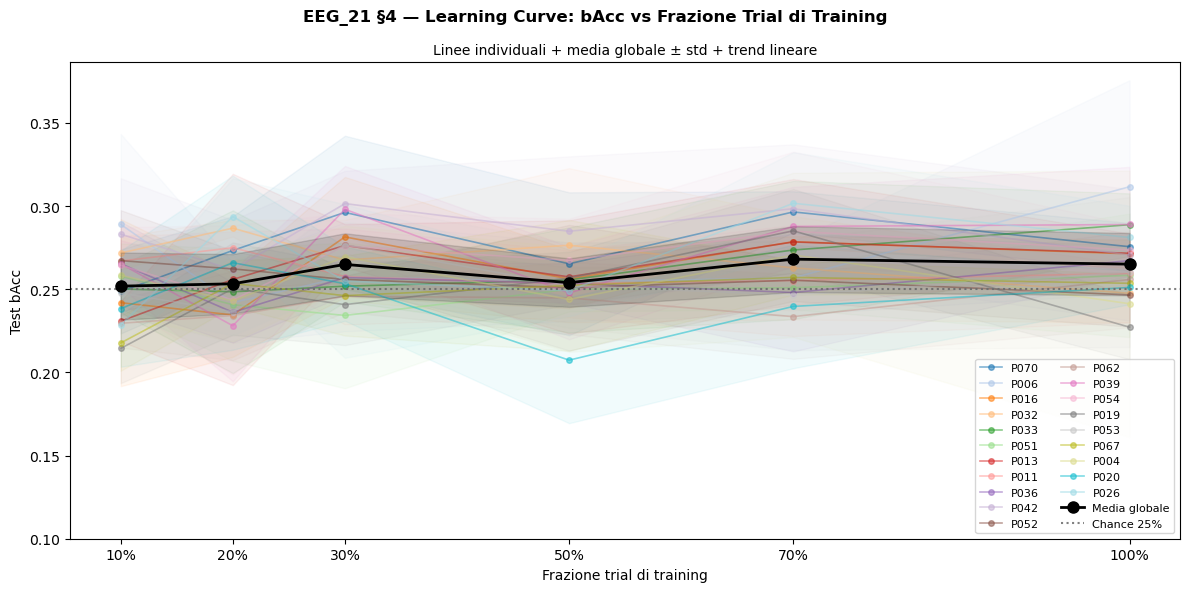


Trend globale: slope=+0.0146  p=0.136  R²=0.465
→ slope ≈ 0 e/o p > 0.05 = plateau confermato

=== SATURAZIONE ===
P070: 100%=0.276  Δ(70→100%)=-0.0209
P006: 100%=0.312  Δ(70→100%)=+0.0548
P016: 100%=0.271  Δ(70→100%)=-0.0073
P032: 100%=0.248  Δ(70→100%)=-0.0153
P033: 100%=0.289  Δ(70→100%)=+0.0152
P051: 100%=0.258  Δ(70→100%)=+0.0075
P013: 100%=0.272  Δ(70→100%)=-0.0068
P011: 100%=0.260  Δ(70→100%)=+0.0044
P036: 100%=0.267  Δ(70→100%)=+0.0192
P042: 100%=0.271  Δ(70→100%)=-0.0278
P052: 100%=0.247  Δ(70→100%)=-0.0089
P062: 100%=0.256  Δ(70→100%)=+0.0223
P039: 100%=0.289  Δ(70→100%)=+0.0012
P054: 100%=0.274  Δ(70→100%)=-0.0113
P019: 100%=0.227  Δ(70→100%)=-0.0580
P053: 100%=0.260  Δ(70→100%)=+0.0138
P067: 100%=0.254  Δ(70→100%)=-0.0036
P004: 100%=0.241  Δ(70→100%)=-0.0294
P020: 100%=0.251  Δ(70→100%)=+0.0114
P026: 100%=0.281  Δ(70→100%)=-0.0206


In [14]:
if not lc_results:
    print('[INFO] Esegui prima §4.')
else:
    import matplotlib.cm as cm
    from scipy.stats import linregress

    COLORS_N = [cm.tab20(i / len(lc_results)) for i in range(len(lc_results))]
    FRACS_X  = sorted(next(iter(lc_results.values())).keys())

    fig, ax = plt.subplots(figsize=(12, 6))
    fig.suptitle('EEG_21 §4 — Learning Curve: bAcc vs Frazione Trial di Training',
                 fontsize=12, fontweight='bold')

    # Raccoglie medie per soggetto per calcolare trend globale
    all_means = []

    for i, (subj_str, frac_dict) in enumerate(lc_results.items()):
        col   = COLORS_N[i]
        fracs = sorted(frac_dict.keys())
        means = [np.mean(frac_dict[f]) for f in fracs]
        stds  = [np.std(frac_dict[f])  for f in fracs]
        all_means.append(means)

        ax.plot(fracs, means, 'o-', color=col, label=subj_str,
                lw=1.2, markersize=4, alpha=0.55)
        ax.fill_between(fracs,
                        [m - s for m, s in zip(means, stds)],
                        [m + s for m, s in zip(means, stds)],
                        color=col, alpha=0.06)

    # Trend globale: media tra tutti i soggetti per frazione
    global_mean = np.mean(all_means, axis=0)   # (n_fracs,)
    global_std  = np.std(all_means,  axis=0)

    ax.plot(FRACS_X, global_mean, 'o-', color='black', lw=2,
            markersize=8, label='Media globale', zorder=10)
    ax.fill_between(FRACS_X,
                    global_mean - global_std,
                    global_mean + global_std,
                    color='black', alpha=0.12, zorder=9)

    

    ax.axhline(CHANCE, color='gray', ls=':', lw=1.5, label=f'Chance {CHANCE:.0%}')
    ax.set_xlabel('Frazione trial di training')
    ax.set_ylabel('Test bAcc')
    ax.set_title('Linee individuali + media globale ± std + trend lineare', fontsize=10)
    ax.set_xticks(FRACS_X)
    ax.set_xticklabels([f'{f:.0%}' for f in FRACS_X])
    ax.legend(loc='lower right', fontsize=8, ncol=2)
    ax.set_ylim(bottom=0.1)

    plt.tight_layout()
    plt.savefig(FIG_DIR / 'eeg21_learning_curve.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f'\nTrend globale: slope={slope:+.4f}  p={p:.3f}  R²={r**2:.3f}')
    print('→ slope ≈ 0 e/o p > 0.05 = plateau confermato')
    print('\n=== SATURAZIONE ===')
    for subj_str, frac_dict in lc_results.items():
        fracs = sorted(frac_dict.keys())
        means = [np.mean(frac_dict[f]) for f in fracs]
        delta_last = means[-1] - means[-2]
        print(f'{subj_str}: 100%={means[-1]:.3f}  Δ(70→100%)={delta_last:+.4f}')

In [11]:
sid = 20
sids = sorted(subj_sess[sid].keys())
train_sess = sids[:-2]
n_total = len(_collect_items(sid, train_sess))
print(f'P020: sessioni train={train_sess}  trial totali={n_total}')

P020: sessioni train=[1, 2, 3, 4]  trial totali=440


## §5 — W&B Summary

Logga tutti i risultati di EEG_21 in un unico run W&B.

In [ ]:
try:
    run21 = wandb.init(
        entity=WANDB_ENTITY, project=WANDB_PROJECT,
        name='eeg21_stability_analysis',
        config={'notebook': 'EEG_21', 'n_top_subj': len(TOP_SUBJ) if 'TOP_SUBJ' in dir() else 0,
                'max_epochs_21': MAX_EPOCHS_21, 'patience_21': PATIENCE_21,
                'lc_fractions': FRACTIONS, 'lc_n_seeds': N_SEEDS},
        reinit='finish_previous',
        settings=wandb.Settings(start_method='thread')
    )

    # §2 per-class
    if 'df_pc' in dir():
        pc_rows = [[row['Subject'], row['bAcc']] + [row[cn] for cn in CLASS_NAMES]
                   for _, row in df_pc.iterrows()]
        pc_tbl = wandb.Table(data=pc_rows, columns=['subject', 'bAcc'] + CLASS_NAMES)
        run21.log({'per_class/table': pc_tbl})
        for cn in CLASS_NAMES:
            run21.summary[f'mean_recall_{cn.lower()}'] = float(df_pc[cn].mean())
        run21.log({'per_class/analysis': wandb.Image(str(FIG_DIR / 'eeg21_per_class_analysis.png'))})

    # §3 stability
    if stability_results:
        run21.log({'stability/heatmap': wandb.Image(str(FIG_DIR / 'eeg21_session_stability.png'))})
        stab_rows = []
        for s, folds in stability_results.items():
            vals = list(folds.values())
            stab_rows.append([s, round(np.mean(vals), 4), round(np.std(vals), 4),
                              round(min(vals), 4), round(max(vals), 4)])
        stab_tbl = wandb.Table(data=stab_rows, columns=['subject','mean','std','min','max'])
        run21.log({'stability/table': stab_tbl})

    # §4 learning curve
    if lc_results:
        run21.log({'learning_curve/plot': wandb.Image(str(FIG_DIR / 'eeg21_learning_curve.png'))})

    run21.finish()
    print('W&B summary loggato: eeg21_stability_analysis')
except Exception as e:
    print(f'W&B fallito: {e}')